In [9]:
from IPython.display import HTML
HTML('''
<script
    src="https://cdnjs.cloudflare.com/ajax/libs/jquery/2.0.3/jquery.min.js ">
</script>
<script>
code_show=true; 
function code_toggle() {
 if (code_show){
 $('div.jp-CodeCell > div.jp-Cell-inputWrapper').hide();
 } else {
$('div.jp-CodeCell > div.jp-Cell-inputWrapper').show();
 }
 code_show = !code_show
} 
$( document ).ready(code_toggle);
</script>
<form action="javascript:code_toggle()"><input type="submit"
    value="Click here to toggle on/off the raw code."></form>
''')

<div align="center">
    <img src="figures/header.png" alt="title_header">
</div>

<h2 style=" color: #212618; font-weight:600;">Introduction</h2>

Amid complex global dynamics, multinational companies face growing exposure to foreign exchange fluctuations, liquidity shifts, and market volatility, which are key components of treasury risk management. To monitor and mitigate these risks, finance analysts rely on treasury dashboards that integrate exposures, FX rates, hedges, positions, and scenario analyses to evaluate potential financial outcomes. However, access to realistic treasury datasets for developing and testing such analytical systems is often limited due to confidentiality and regulatory constraints surrounding corporate financial data.
We introduce **NextHedge**, a synthetic data generator that simulates realistic treasury risk environments by producing structured datasets for exposures, FX rates, hedges, positions, and scenarios, enabling the development and evaluation of treasury risk dashboards.



<h2 style=" color: #212618; font-weight:600;">Methodology</h2>

The methodology is structured into two sections, a discussion of the how the data was consolidated and the general assumptions held to ground the synthetic data generator.

<h3 style=" color: #212618; font-weight:600;">Overview</h3>

<div align="center">
    <img src="figures/diagram.png" alt="methodology">
    <div style="font-size:14px; font-style:default; text-align:center">
        <b>Figure 1. Data Consolidation Diagram</b><br><br>
    </div>
</div>

Figure 1 illustrates three independent simulation mechanisms we integrated in NextHedge—FX Market Behavior, Exposure Behavior, and Hedge Behavior. Each generate their own data streams, which we then stress-tested through optional Scenario Injection before consolidating through Risk Metric Derivation into the final dataset.

<h3 style=" color: #212618; font-weight:600;">Model Assumptions</h3>

The NextHedge simulator operates under these assumptions we set to simplify the nuances faced by global financial markets and internal business operations.

1. **Exposure is modeled at the transaction level using a Poisson arrival process with lognormal amounts, representing day-to-day invoices and payables.** Translational and economic exposure are excluded as transactional exposure is the dominant hedgeable component for most non-financial corporates.
2. **FX dynamics and exposure evolve as independent processes.** Feedback effects — such as currency movements influencing procurement volumes — are excluded to avoid loops that require firm-specific empirical calibration.
3. **GARCH parameters are calibrated for short-to-medium term horizons.** Constraints are enforced to ensure volatility is mean-reverting and does not drift unrealistically over the simulation window.
4. **Hedge behavior is purely policy-driven**, modeled as a fixed target ratio plus operational noise. The generator assumes treasury follows a standing hedging mandate rather than actively timing or optimizing the market.
5. **The hedge contract rate is derived from Interest Rate Parity at a fixed tenor per maturity bucket**, assuming hedges are entered at theoretically fair forward rates with no transaction costs, counterparty premium, or liquidity adjustment.
6. **Stress scenarios are assigned probabilistically per entity-currency pair**, reflecting that real portfolios contain a mix of stressed and unstressed positions simultaneously rather than a single global stress condition.

With this, NextHedge generates a dataset with a grain of `[valuation_date × legal_entity × currency × maturity_bucket]` to create distinct sequential rows. As covered in Table 1, each row contains the following columns 

<div style="font-size:14px; font-style:default; text-align:center">
    <b>Table 1. Dataset Features</b><br><br>
          
| Field Name | Description |
| :--- | :--- |
| **`valuation_date`** | **Valuation Date:** The business day on which all positions, rates, and risk metrics are recorded. |
| **`legal_entity`** | **Legal Entity:** The corporate entity holding the FX exposure. |
| **`currency`** | **Foreign Currency:** The currency of the exposure being managed relative to PHP. |
| **`maturity_bucket`** | **Maturity Bucket:** The tenor of the hedge contract (e.g., 1M, 3M, 6M). |
| **`exposure_type`** | **Exposure Type:** Nature of the transaction — transactional, forecast, or translational. |
| **`days_to_maturity`** | **Days to Maturity:** Calendar days until the transaction settles, sampled within the maturity bucket range. |
| **`scenario`** | **Scenario:** Stress condition assigned to the entity-currency pair — `none`, `fx_shock`, `vol_shock`, or `under_hedge`. |
| **`spot_rate`** | **Spot Rate:** The simulated daily exchange rate expressed as PHP per unit of foreign currency. |
| **`fx_volatility`** | **FX Volatility:** The conditional daily volatility of the spot rate, output from the GARCH process. |
| **`gross_exposure_fc`** | **Gross Exposure (FC):** Total foreign currency obligation of the entity before any hedging. |
| **`hedge_ratio_actual`** | **Actual Hedge Ratio:** The realized proportion of gross exposure covered by hedges on a given day. |
| **`hedge_notional_fc`** | **Hedge Notional (FC):** The foreign currency amount actively covered by hedge contracts. |
| **`net_exposure_fc`** | **Net Exposure (FC):** The residual unhedged foreign currency exposure remaining after hedging. |
| **`net_exposure_dc`** | **Net Exposure (DC):** The net unhedged exposure converted to Philippine Peso at the prevailing spot rate. |
| **`coverage_ratio`** | **Coverage Ratio:** The proportion of gross exposure covered by active hedge contracts. |
| **`hedge_contract_rate`** | **Hedge Contract Rate:** The forward rate at which the hedge position was locked in. |
| **`mtm_hedge`** | **Mark-to-Market Hedge PnL:** The unrealized gain or loss on the hedge book relative to the current spot rate. |
| **`fx_delta`** | **FX Delta:** The sensitivity of the portfolio value to a unit movement in the spot rate. |
| **`fx_delta_1pct`** | **FX Delta (1% Move):** Estimated PHP gain or loss on the net position for a 1% spot rate movement. |
| **`tenor_weight`** | **Tenor Weight:** Days to maturity as a fraction of a year, used to weight exposure by time sensitivity. |
| **`vol_adjusted_exposure`** | **Volatility-Adjusted Exposure:** Net DC exposure scaled by prevailing FX volatility. |
| **`duration_weighted_exposure`** | **Duration-Weighted Exposure:** Net DC exposure scaled by tenor weight. |
| **`VaR_95`** | **Value at Risk (95%):** Estimated maximum loss on the net position under normal market conditions at 95% confidence. |
| **`stress_loss_10pct`** | **Stress Loss (10% Depreciation):** Estimated PHP loss on the net position under a sudden 10% depreciation scenario. |
| **`hedge_ratio_policy`** | **Policy Hedge Ratio:** The entity's target proportion of exposure to be hedged under normal operating conditions. |
| **`risk_limit_net_fc`** | **Risk Limit (Net FC):** The maximum allowable net unhedged exposure as defined by the entity's risk policy. |
| **`base_currency`** | **Base Currency:** The domestic reporting currency for all DC conversions. Fixed as PHP. |
| **`hedge_rebalance_frequency`** | **Rebalance Frequency:** Number of days between scheduled hedge reviews under the entity's policy. |
| **`volatility_limit`** | **Volatility Limit:** The maximum annualised FX volatility tolerated before escalating risk actions. |
| **`limit_breach`** | **Limit Breach Flag:** Indicates whether the net unhedged exposure has exceeded the entity's risk limit. |
    
</div>

<h2 style=" color: #212618; font-weight:600;">Use Cases</h2>

To showcase the data further, we suggested some use cases below for treasury risk management. For reproducibility of the insights in this section, we will use the `synthetic_treasury_risk_data.csv` file which will definitely differ on new instances of data generation.

In [2]:
import sys
import os
sys.path.append(os.path.abspath("../scripts"))

from data_viz import plot_treasury_dashboard
from forecasting import forecast_treasury_risk

<h3 style=" color: #212618; font-weight:600;">1. Treasury Risk Dashboard</h3>

We posit this as the main use case for NextHedge—to screen treasury conditions with sequential data of various entities, maturity buckets, time periods, and currencies. `data_viz.py` contains ways the dashboard can be configured based on what is available in the generated data.

/var/folders/4h/l_r82x1x54j401nyjsmtbgfw0000gq/T/ipykernel_16372/2685620943.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


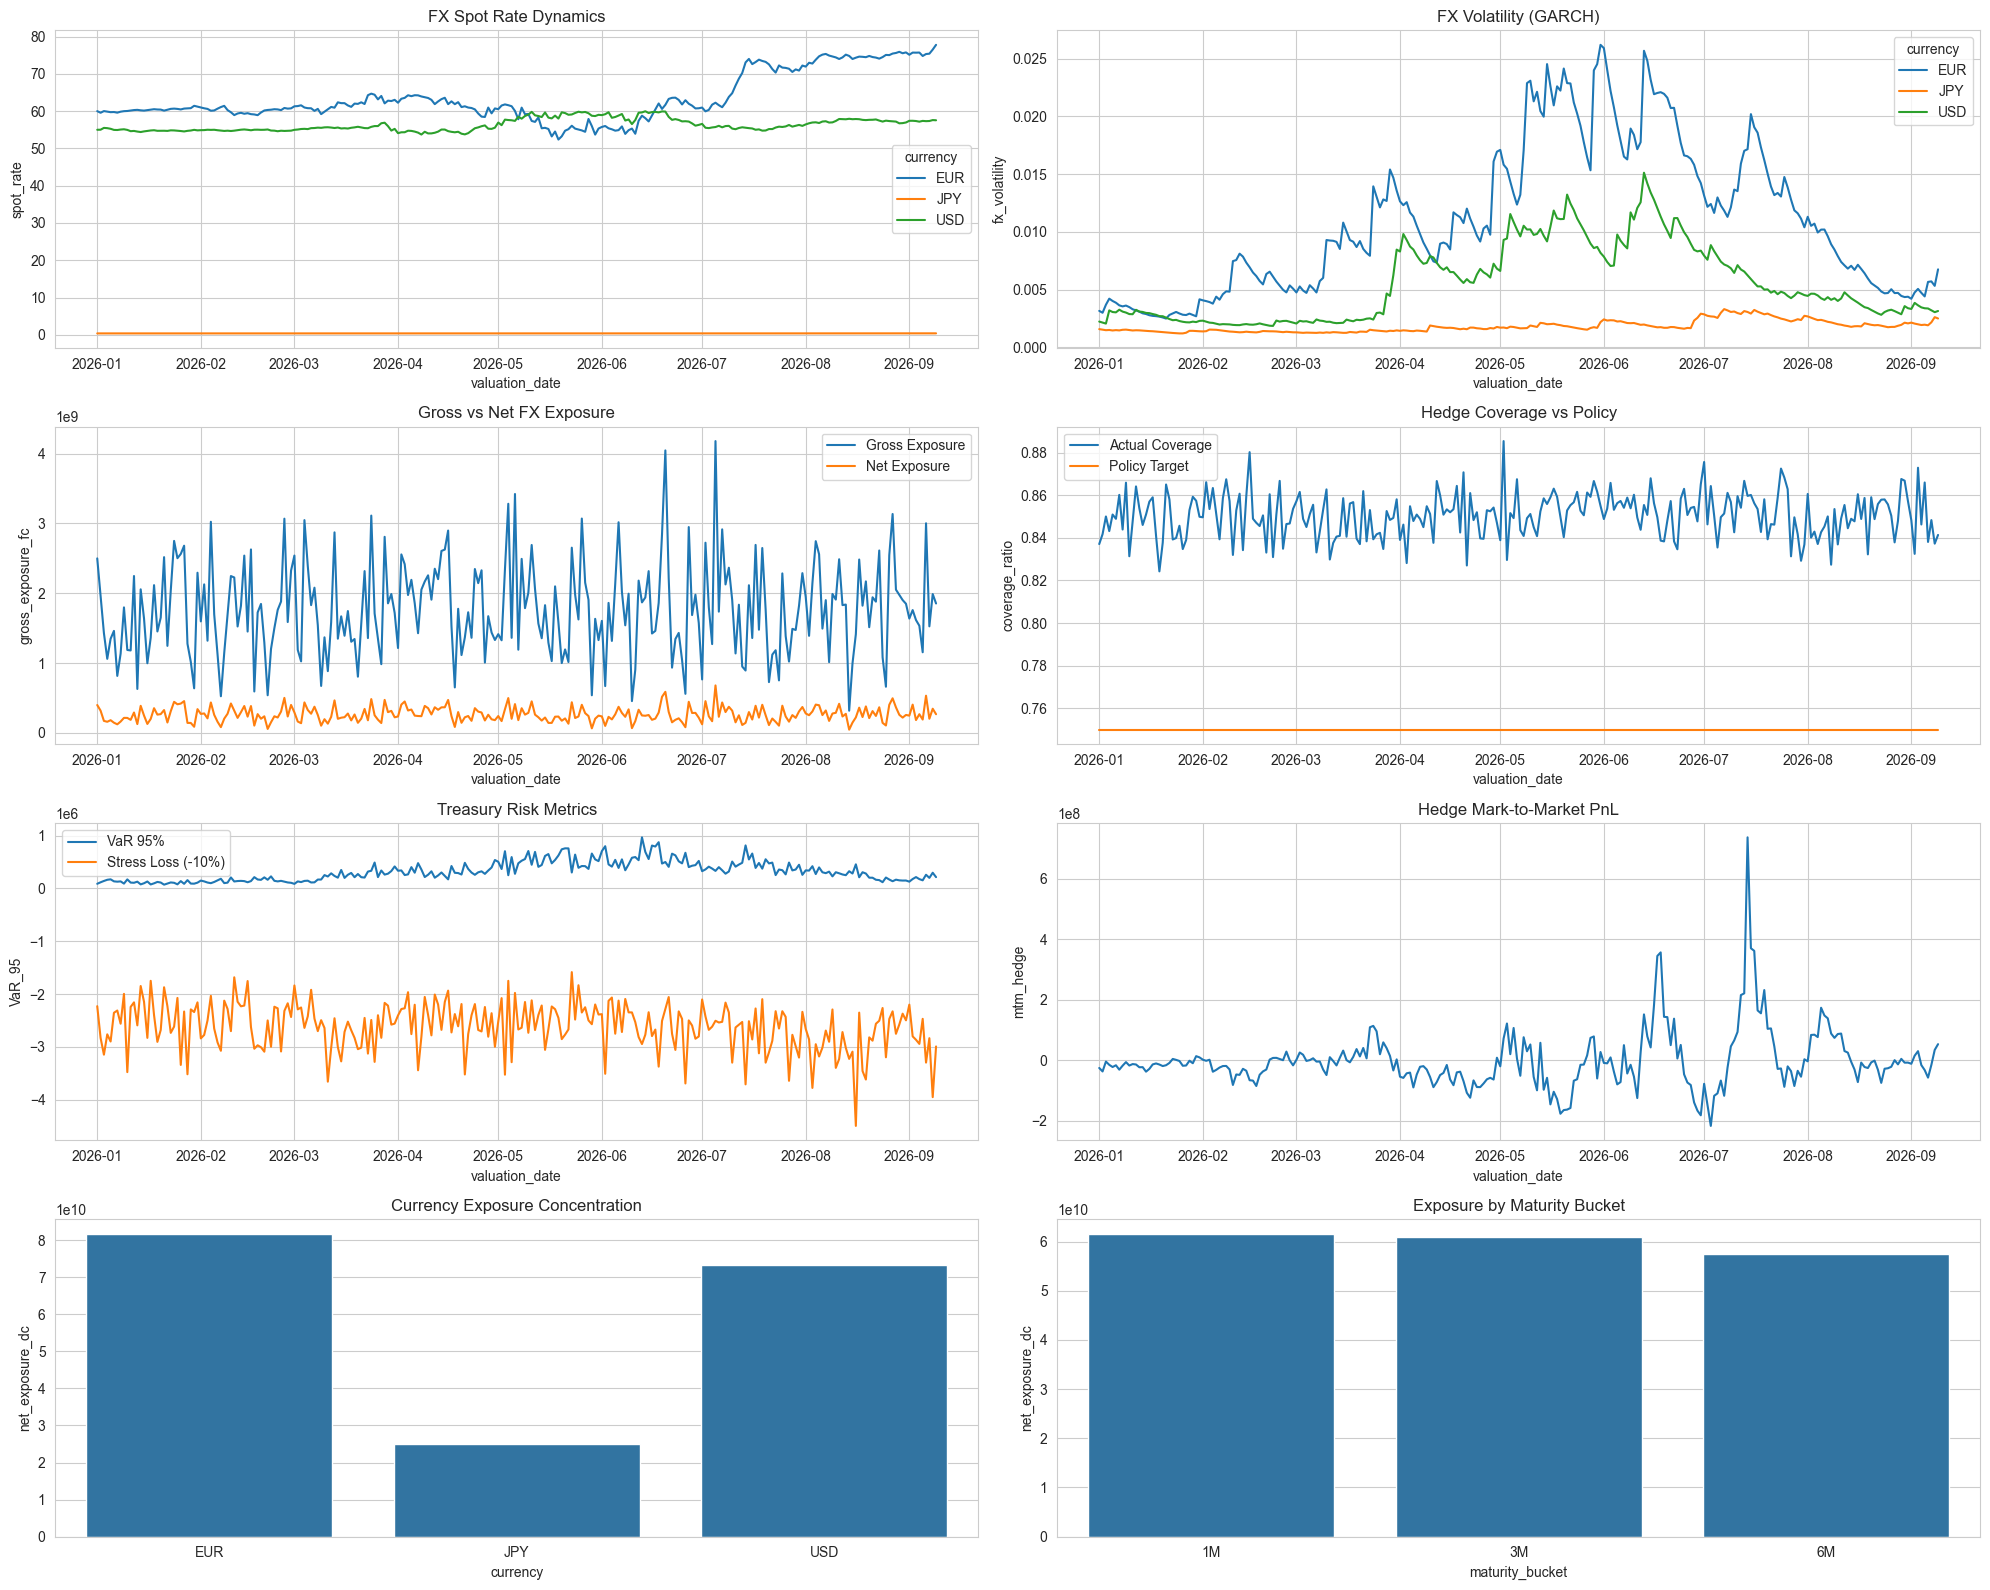

In [4]:
fig = plot_treasury_dashboard(
    "../data/synthetic_treasury_risk_data.csv",  # Change filepath based on file location
    entity="TechCorp"
)

fig.show()

<div style="font-size:14px; font-style:default; text-align:center">
    <b>Figure 2. Treasury Risk Dashboard</b><br><br>
</div>

As seen on Figure 2, the dashboard showcases the capabilities of NextHedge to model realistic trends. Beyond the expected volatility, the `Hedge Mark-to-Market PnL` chart showcases a scenario where the company is generally stable until the 2nd quarter where continuous reversals happen until peaking at July 2026 where hedges return to stable results. The addition of certain variables in the generator could potentially contribute to its sensitivity, hence the reactionary behavior observed for this entity. The time-series element is a central component of making production-level dashboards like this, albeit some issues with scaling due to the nominal values of currencies like `JPY` compared to higher valued `USD` and `EUR` which can be seen in the `FX Spot Rate Dynamics` and `Currency Exposure Concentration` charts. Nonetheless, the charts exhibit the potential synergistic analysis for finance analysts, which is the goal of the generator. 

<h3 style=" color: #212618; font-weight:600;">2. Forecasting</h3>

Although more experimental, we see the potential for NextHedge to aid in learning time series trends in financial markets. For this we implemented a basic ARIMA model to demonstrate forecasting capabilities on `net_exposure_dc` or the unhedged value of the Philippine Peso in a deal. We recognize the model's tendency to trend on the mean instead of following large shocks, hence this could be a future direction to improving data quality of NextHedge or implementing more sophisticated forecasting methods available.

ADF p-value: 0.0037 → using ARIMA(2, 0, 2)


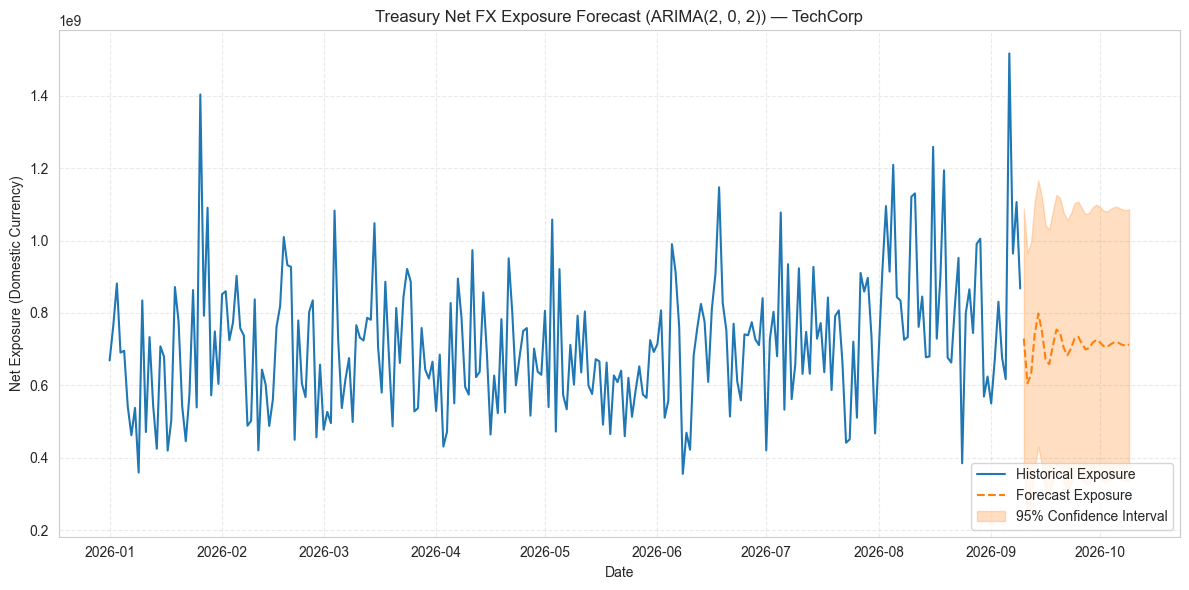

                               SARIMAX Results                                
Dep. Variable:        net_exposure_dc   No. Observations:                  252
Model:                 ARIMA(2, 0, 2)   Log Likelihood               -5147.521
Date:                Wed, 11 Mar 2026   AIC                          10307.043
Time:                        21:55:06   BIC                          10328.219
Sample:                    01-01-2026   HQIC                         10315.564
                         - 09-09-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        7.14e+08   2.69e-11   2.66e+19      0.000    7.14e+08    7.14e+08
ar.L1          0.6708      0.085      7.884      0.000       0.504       0.838
ar.L2         -0.7779      0.089     -8.712      0.0

In [5]:
forecast = forecast_treasury_risk(
    "../data/synthetic_treasury_risk_data.csv", # Change filepath based on file location
    entity="TechCorp",
    forecast_days=30
)